Homework  1  --  Machine  Learning  in  Finance  --  Group  3

Quesion  1

2026-03-10 22:03:26.067393: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Training image number 46250 belongs to class: 0 - T-shirt/top


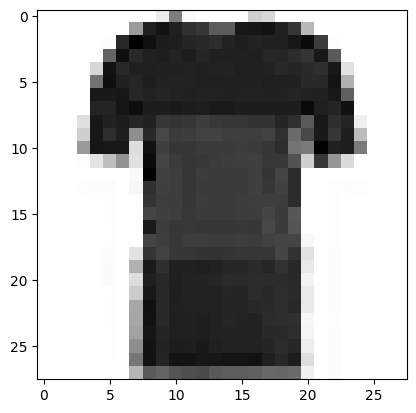

x_train shape: (60000, 28, 28, 1)
Number of training images: 60000
Number of test images: 10000
y_train shape: (60000,)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8291 - loss: 0.4778
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8699 - loss: 0.3543
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8834 - loss: 0.3168
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8906 - loss: 0.2954
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8972 - loss: 0.2757
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9010 - loss: 0.2611
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9078 - loss: 0.2483
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9099 - loss: 0.2394
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9143 - loss: 0.2274
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9187 - loss: 0.2157
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8895 - loss: 0.3343
Test result [loss, accuracy] = [0.3342856466770172, 0.8895000219

In [ ]:
## Loading packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

## Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Function to display an image
def show(i, T=0):
    if T == 0:
        print("Training image number", i, "belongs to class:", y_train[i], "-", class_names[y_train[i]])
        plt.imshow(x_train[i], cmap='Greys')
        plt.show()
    else:
        print("Test image number", i, "belongs to class:", y_test[i], "-", class_names[y_test[i]])
        plt.imshow(x_test[i], cmap='Greys')
        plt.show()

## Show one random training image
image_index = np.random.randint(60000)
show(image_index)

## Reshape data to 4D tensors for Keras
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

## Convert to float
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

## Normalize pixel values to [0,1]
x_train /= 255
x_test /= 255

print("x_train shape:", x_train.shape)
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])
print("y_train shape:", y_train.shape)

## Import model/layers
from keras.models import Model
from keras.layers import Input, Dense, Flatten

## Define model
inputs = Input(shape=input_shape)
outputs = Flatten()(inputs)
outputs = Dense(512, activation='relu')(outputs)
outputs = Dense(256, activation='relu')(outputs)
outputs = Dense(10, activation='softmax')(outputs)

model = Model(inputs=inputs, outputs=outputs)

## Summary
model.summary()

## Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train model
model.fit(x=x_train, y=y_train, epochs=10, batch_size=100)

## Evaluate on test set
results = model.evaluate(x_test, y_test)
print("Test result [loss, accuracy] =", results)

Question  2

[(a)  f(x) = exp(x)]  Final training MSE: 0.000009
[(b)  f(x) = cos(3x² − 1)]  Final training MSE: 0.000020


(<Functional name=functional_6, built=True>,
 <keras.src.callbacks.history.History at 0x1b52e62d0>)

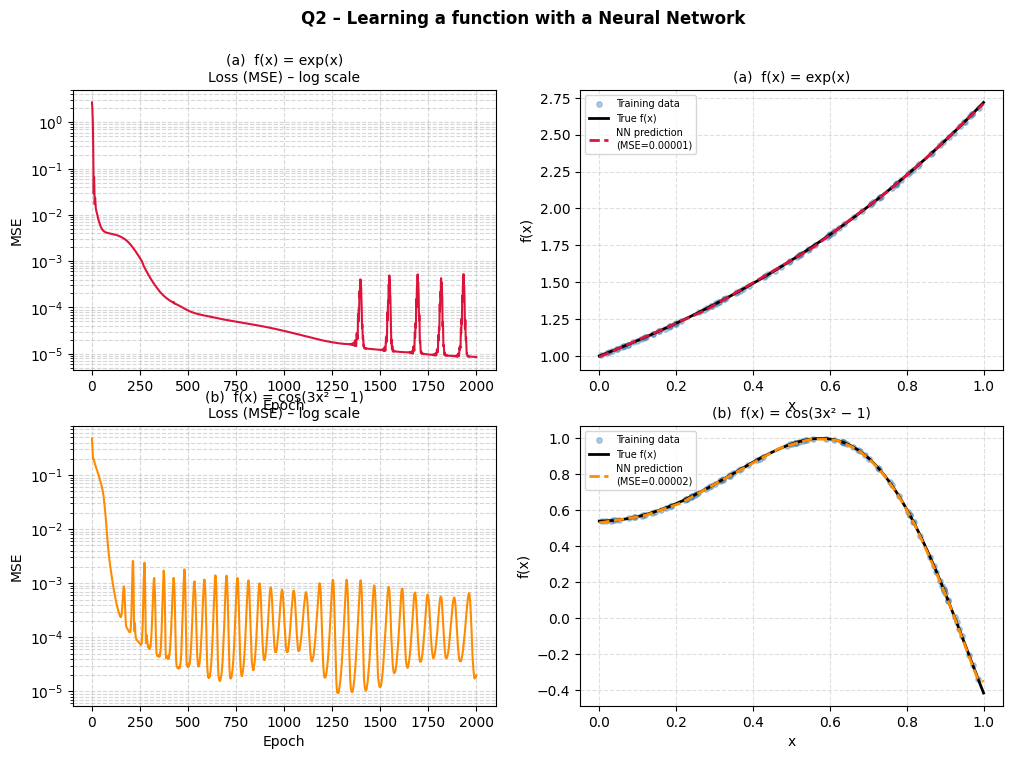

In [ ]:
# -*- coding: utf-8 -*-
"""
Learning a function with a neural network
Functions:
  (a) f(x) = exp(x)
  (b) f(x) = cos(3x² - 1)
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam

# ── Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ── Target functions
def f_a(x):
    """(a) f(x) = exp(x)"""
    return np.exp(x)

def f_b(x):
    """(b) f(x) = cos(3x² - 1)"""
    return np.cos(3 * x**2 - 1)

# ── Build neural network
def build_model(hidden_layers=(64, 64, 32)):
    """
    Fully-connected network:
      - Input: scalar x  (shape [1])
      - Hidden layers: ReLU activations
      - Output: linear readout (shape [1], no activation)
    """
    inp = Input(shape=(1,))
    x = inp
    for units in hidden_layers:
        x = Dense(units, activation='relu')(x)
    out = Dense(1, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    return model

# ── Training helper
def train_and_plot(f, label, ax_loss, ax_fit, color_true='black', color_pred='crimson'):
    # --- Training data: N=100 uniform samples on [0,1] ---
    N = 100
    x_train = np.random.uniform(0, 1, N).astype('float32')
    y_train = f(x_train).astype('float32')

    # --- Dense grid for plotting the true curve ---
    x_plot = np.linspace(0, 1, 500).astype('float32')
    y_true = f(x_plot)

    # --- Build and train ---
    model = build_model(hidden_layers=(64, 64, 32))

    history = model.fit(
        x_train, y_train,
        epochs=2000,
        batch_size=32,
        verbose=0
    )

    # --- Predict on dense grid ---
    y_pred = model.predict(x_plot, verbose=0).flatten()

    final_mse = history.history['loss'][-1]
    print(f"[{label}]  Final training MSE: {final_mse:.6f}")

    # --- Loss curve ---
    ax_loss.semilogy(history.history['loss'], color=color_pred)
    ax_loss.set_title(f'{label}\nLoss (MSE) – log scale', fontsize=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE')
    ax_loss.grid(True, which='both', ls='--', alpha=0.5)

    # --- comparison ---
    ax_fit.scatter(x_train, y_train, s=15, alpha=0.4,
                   color='steelblue', label='Training data', zorder=2)
    ax_fit.plot(x_plot, y_true,  color=color_true,  lw=2,   label='True f(x)',      zorder=3)
    ax_fit.plot(x_plot, y_pred,  color=color_pred,  lw=2,
                ls='--', label=f'NN prediction\n(MSE={final_mse:.5f})', zorder=4)
    ax_fit.set_title(f'{label}', fontsize=10)
    ax_fit.set_xlabel('x')
    ax_fit.set_ylabel('f(x)')
    ax_fit.legend(fontsize=7)
    ax_fit.grid(True, ls='--', alpha=0.4)

    return model, history

# ── Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Q2 – Learning a function with a Neural Network\n' ,
             fontsize=12, fontweight='bold')

train_and_plot(f_a, '(a)  f(x) = exp(x)',
               ax_loss=axes[0, 0], ax_fit=axes[0, 1],
               color_true='black', color_pred='crimson')

train_and_plot(f_b, '(b)  f(x) = cos(3x² − 1)',
               ax_loss=axes[1, 0], ax_fit=axes[1, 1],
               color_true='black', color_pred='darkorange')



## Does it work? How many nodes are needed?

Yes, it works pretty well for both functions. With 3 hidden layers (64–64–32 ReLU units) and a linear output, the network achieves final MSEs of **0.000009** for exp(x) and **0.000020** for cos(3x²−1), which is already very small. Looking at the fit plots, the NN prediction basically overlaps with the true function in both cases.

In terms of node count, (≈6k parameters) is honestly overkill for a smooth 1D function. The Universal Approximation Theorem tells us a single hidden layer with enough units is theoretically sufficient.

## Different Behaviour for the Two Functions?

Yes, and it's quite visible in the loss curves:

- **f(x) = exp(x):** loss drops fast and fairly smoothly, reaching ~10⁻⁵ within a few hundred epochs. There are some spikes later in training (around epochs 1300–2000) which are just occasionally overshooting, but it recovers. Makes sense because exp(x) is monotone and smooth, so it's an easy target.

- **f(x) = cos(3x²−1):** the loss oscillates persistently throughout all 2000 epochs and never really stabilises, t still converges to a comparably low MSE in the end, so the network handles it fine.

## More Training Data / Deeper Network?

Since there's no noise here , going from N=100 to say N=500 wouldn't dramatically change the training MSE, the network already fits well. It would mostly help fill in gaps between training points and likely make the loss curve for function (b) less noisy.
For deeper networks, going beyond 3 layers doesn't really help much for smooth 1D functions like these because they're just not complex enough to benefit from extra depth. So overall the current setup is already a good fit for the problem. Check below code !

[(a)  f(x) = exp(x)]  Final training MSE: 0.000004
[(b)  f(x) = cos(3x² − 1)]  Final training MSE: 0.000001


(<Functional name=functional_4, built=True>,
 <keras.src.callbacks.history.History at 0x1504f9090>)

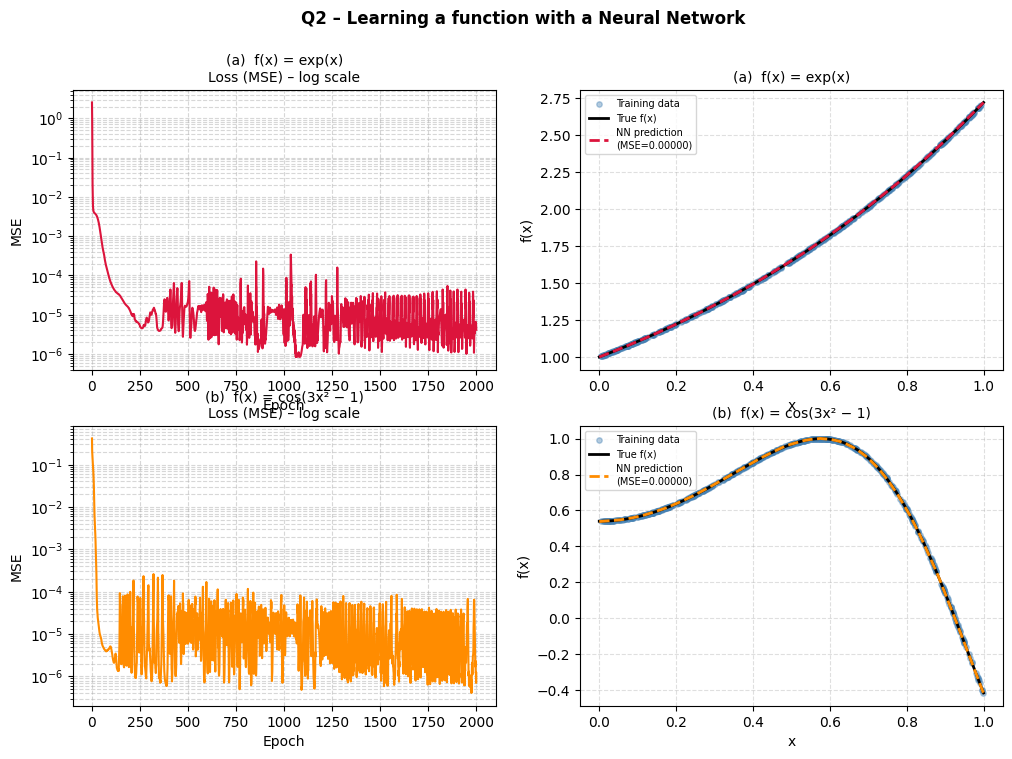

In [ ]:
# -*- coding: utf-8 -*-
"""
Learning a function with a neural network
Functions:
  (a) f(x) = exp(x)
  (b) f(x) = cos(3x² - 1)
"""

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam

# ── Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ── Target functions
def f_a(x):
    """(a) f(x) = exp(x)"""
    return np.exp(x)

def f_b(x):
    """(b) f(x) = cos(3x² - 1)"""
    return np.cos(3 * x**2 - 1)

# ── Build neural network
def build_model(hidden_layers=(64, 64, 32)):
    """
    Fully-connected network:
      - Input: scalar x  (shape [1])
      - Hidden layers: ReLU activations
      - Output: linear readout (shape [1], no activation)
    """
    inp = Input(shape=(1,))
    x = inp
    for units in hidden_layers:
        x = Dense(units, activation='relu')(x)
    out = Dense(1, activation='linear')(x)
    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
    return model

# ── Training helper
def train_and_plot(f, label, ax_loss, ax_fit, color_true='black', color_pred='crimson'):
    # --- Training data: N=100 uniform samples on [0,1] ---
    N = 500
    x_train = np.random.uniform(0, 1, N).astype('float32')
    y_train = f(x_train).astype('float32')

    # --- Dense grid for plotting the true curve ---
    x_plot = np.linspace(0, 1, 500).astype('float32')
    y_true = f(x_plot)

    # --- Build and train ---
    model = build_model(hidden_layers=(64, 64, 64,32)) # DEEPER NEURAL NETWORK

    history = model.fit(
        x_train, y_train,
        epochs=2000,
        batch_size=32,
        verbose=0
    )

    # --- Predict on dense grid ---
    y_pred = model.predict(x_plot, verbose=0).flatten()

    final_mse = history.history['loss'][-1]
    print(f"[{label}]  Final training MSE: {final_mse:.6f}")

    # --- Loss curve ---
    ax_loss.semilogy(history.history['loss'], color=color_pred)
    ax_loss.set_title(f'{label}\nLoss (MSE) – log scale', fontsize=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('MSE')
    ax_loss.grid(True, which='both', ls='--', alpha=0.5)

    # --- comparison ---
    ax_fit.scatter(x_train, y_train, s=15, alpha=0.4,
                   color='steelblue', label='Training data', zorder=2)
    ax_fit.plot(x_plot, y_true,  color=color_true,  lw=2,   label='True f(x)',      zorder=3)
    ax_fit.plot(x_plot, y_pred,  color=color_pred,  lw=2,
                ls='--', label=f'NN prediction\n(MSE={final_mse:.5f})', zorder=4)
    ax_fit.set_title(f'{label}', fontsize=10)
    ax_fit.set_xlabel('x')
    ax_fit.set_ylabel('f(x)')
    ax_fit.legend(fontsize=7)
    ax_fit.grid(True, ls='--', alpha=0.4)

    return model, history

# ── Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Q2 – Learning a function with a Neural Network\n' ,
             fontsize=12, fontweight='bold')

train_and_plot(f_a, '(a)  f(x) = exp(x)',
               ax_loss=axes[0, 0], ax_fit=axes[0, 1],
               color_true='black', color_pred='crimson')

train_and_plot(f_b, '(b)  f(x) = cos(3x² − 1)',
               ax_loss=axes[1, 0], ax_fit=axes[1, 1],
               color_true='black', color_pred='darkorange')
